# Ad Hoc Stats

This notebook contains exploratory and supplementary analyses based on the intent classification outputs.

In [1]:
import pandas as pd

df_classifications = pd.read_csv(
    "../data/classifications/classifications_for_analysis.csv"
)

## Message Length Distribution by Intent Labels

Compute message lengths from the `content` column, print summary stats by `main_category` and `sub_category`, and visualize distributions with inline box plots.

In [2]:
import matplotlib.pyplot as plt

# Compute message length features from full user message content.
df_lengths = df_classifications.copy()
df_lengths["content"] = df_lengths["content"].fillna("")
df_lengths["message_length_chars"] = df_lengths["content"].str.len()

# Compute the percentage of messsages that are <=50 chars and >1000 chars
df_lengths["is_short"] = df_lengths["message_length_chars"] <= 50
df_lengths["is_long"] = df_lengths["message_length_chars"] > 1000
print(
    "Percentage of messages ≤50 chars:", f"{df_lengths['is_short'].mean() * 100:.2f}%"
)
print(
    "Percentage of messages >1000 chars:", f"{df_lengths['is_long'].mean() * 100:.2f}%"
)


def length_stats_by_group(df, group_col, length_col):
    return (
        df.groupby(group_col)[length_col]
        .agg(
            n="count",
            mean="mean",
            median="median",
            std="std",
            min="min",
            p25=lambda s: s.quantile(0.25),
            p75=lambda s: s.quantile(0.75),
            p90=lambda s: s.quantile(0.90),
            p95=lambda s: s.quantile(0.95),
            max="max",
        )
        .sort_values("median", ascending=False)
        .round(2)
    )


main_char_stats = length_stats_by_group(
    df_lengths, "main_category", "message_length_chars"
)
sub_char_stats = length_stats_by_group(
    df_lengths, "sub_category", "message_length_chars"
)

print("=== Message Length Stats (Characters) by main_category ===")
display(main_char_stats)

print("=== Message Length Stats (Characters) by sub_category ===")
display(sub_char_stats)

Percentage of messages ≤50 chars: 33.77%
Percentage of messages >1000 chars: 9.02%
=== Message Length Stats (Characters) by main_category ===


,n,mean,median,std,min,p25,p75,p90,p95,max
main_category,,,,,,,,,,
2. Failure Reporting,20527,1332.30,163.0,6234.66,0,60.0,620.0,2434.6,5284.70,255771
4. Context Specification,10948,1243.62,144.0,6078.91,1,56.0,418.0,2069.6,5046.30,183378
1. Code Authoring,28435,447.50,92.0,3291.95,1,45.0,206.0,488.0,1089.30,255771
3. Inquiry,14666,342.47,78.0,2512.36,1,40.0,166.0,384.5,781.00,137870
5. Validation,3001,606.26,76.0,4117.45,2,35.0,178.0,477.0,1513.00,116945
6. Delegation,13016,542.26,65.0,3901.09,1,27.0,176.0,578.5,1668.25,183378
7. Workflow Control,8822,137.91,16.0,1788.91,1,7.0,39.0,99.0,185.95,73816


=== Message Length Stats (Characters) by sub_category ===


,n,mean,median,std,min,p25,p75,p90,p95,max
sub_category,,,,,,,,,,
2.1 Log Paste,6631,2863.52,718.0,9458.00,7,271.5,2115.0,5892.0,11011.00,255771
4.1 Information Injection,6342,1709.38,162.0,7251.68,1,62.0,598.0,3266.3,7121.50,163762
1.1 New Implementation,4397,632.97,137.0,2798.06,2,58.0,326.0,770.4,2438.00,96957
4.2 Behavior Specification,4606,602.33,123.0,3837.17,2,48.0,296.0,935.5,2112.00,183378
3.1 Planning & Decision Consultation,5856,494.53,111.0,3189.29,1,53.0,255.0,647.5,1411.00,137870
6.1 Documentation,5140,875.14,104.0,5654.25,2,49.0,307.0,1084.0,2734.05,183378
2.2 Symptom Description,11075,604.30,102.0,3501.36,0,47.0,236.0,753.6,1953.60,167380
1.2 Iterative Modification,18627,464.49,89.0,3700.31,1,44.0,191.0,466.0,1086.40,255771
5.1 Code Review,2057,630.71,85.0,4428.00,2,41.0,198.0,450.4,1164.20,116945


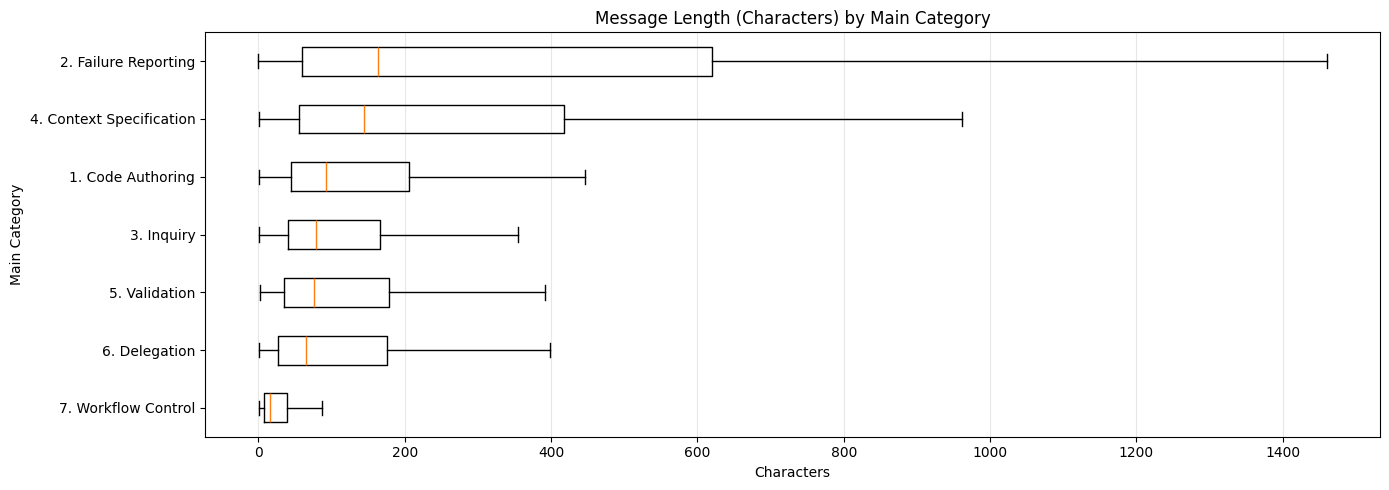

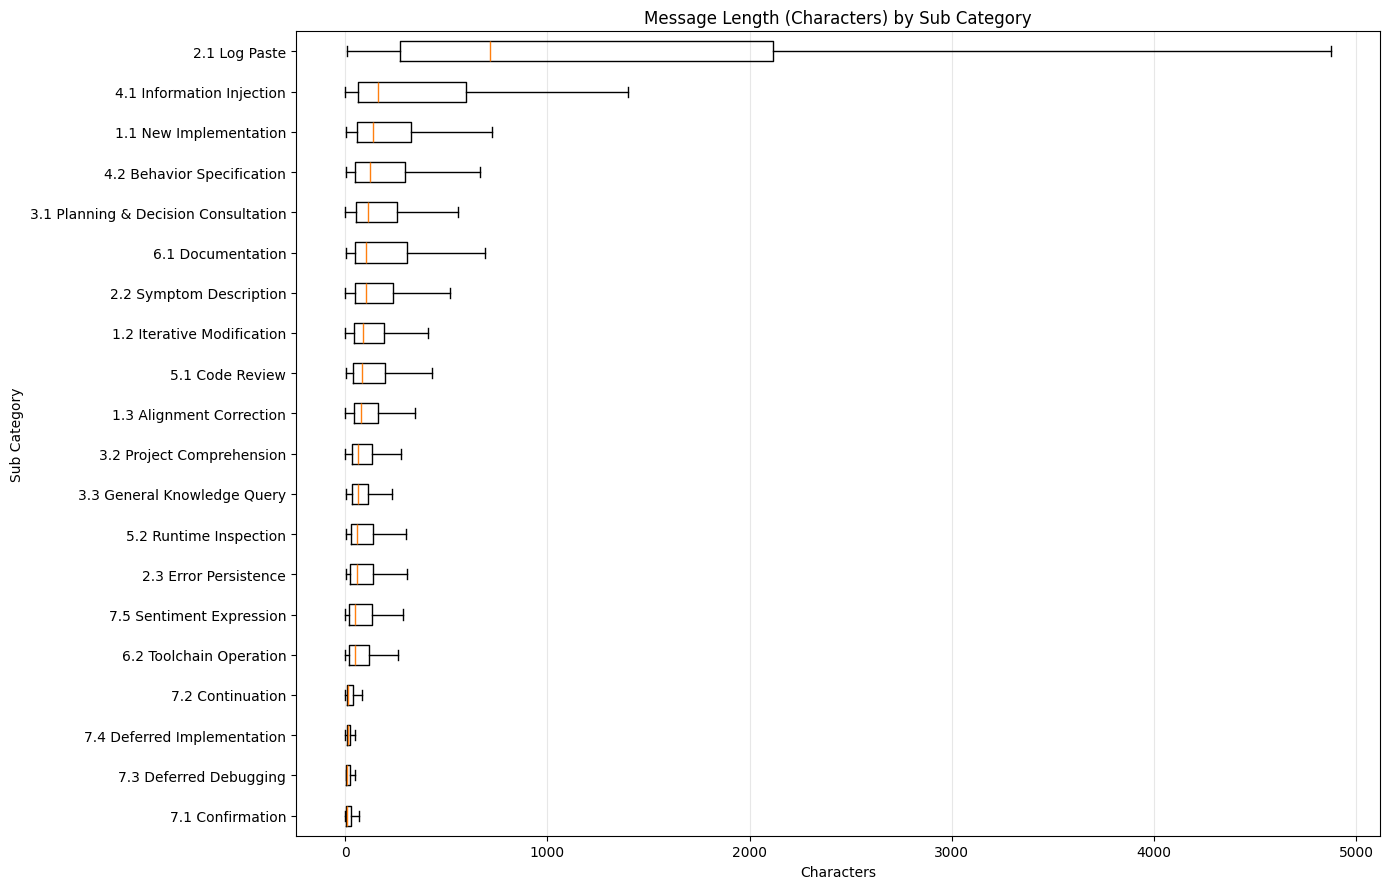

In [3]:
# Inline box plots for character length distributions.
main_order = (
    df_lengths.groupby("main_category")["message_length_chars"]
    .median()
    .sort_values(ascending=True)
    .index
)

sub_order = (
    df_lengths.groupby("sub_category")["message_length_chars"]
    .median()
    .sort_values(ascending=True)
    .index
)

main_data = [
    df_lengths.loc[df_lengths["main_category"] == cat, "message_length_chars"].values
    for cat in main_order
]
sub_data = [
    df_lengths.loc[df_lengths["sub_category"] == cat, "message_length_chars"].values
    for cat in sub_order
]

fig_h_main = max(5, int(len(main_order) * 0.6))
fig_h_sub = max(8, int(len(sub_order) * 0.45))

plt.figure(figsize=(14, fig_h_main))
plt.boxplot(main_data, vert=False, tick_labels=main_order, showfliers=False)
plt.title("Message Length (Characters) by Main Category")
plt.xlabel("Characters")
plt.ylabel("Main Category")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, fig_h_sub))
plt.boxplot(sub_data, vert=False, tick_labels=sub_order, showfliers=False)
plt.title("Message Length (Characters) by Sub Category")
plt.xlabel("Characters")
plt.ylabel("Sub Category")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

## OPENING vs NON-OPENING: Message Length, Label Count, Category Distribution
This cell computes and prints statistics for opening (first) messages versus non-opening messages. Outputs include mean values, percent changes, t-test p-values, and detailed comparisons of main/sub category distributions.

In [4]:
import numpy as np
from scipy.stats import ttest_ind

message_keys = ["sha", "index_in_chat"]
df = df_classifications.copy()
df["content"] = df["content"].fillna("")
df["message_length_chars"] = df["content"].str.len()
df["is_opening"] = df["index_in_chat"] == 0
opening = df[df["is_opening"]]
non_opening = df[~df["is_opening"]]


def dedup_category(df, group_col):
    return df[[group_col, *message_keys]].drop_duplicates().groupby(group_col).size()


# Deduplicate to message level for stats
total_opening = opening[message_keys].drop_duplicates().shape[0]
total_non_opening = non_opening[message_keys].drop_duplicates().shape[0]
# Message length stats (dedup to message level)
mean_opening = opening.drop_duplicates(message_keys)["message_length_chars"].mean()
mean_non_opening = non_opening.drop_duplicates(message_keys)[
    "message_length_chars"
].mean()
pct_change_len = 100 * (mean_opening - mean_non_opening) / mean_non_opening
ttest_len = ttest_ind(
    opening.drop_duplicates(message_keys)["message_length_chars"],
    non_opening.drop_duplicates(message_keys)["message_length_chars"],
    equal_var=False,
)
# Label count stats
label_counts_opening = opening.groupby(message_keys)["label_rank"].max()
label_counts_non_opening = non_opening.groupby(message_keys)["label_rank"].max()
mean_label_opening = label_counts_opening.mean()
mean_label_non_opening = label_counts_non_opening.mean()
pct_change_label = (
    100 * (mean_label_opening - mean_label_non_opening) / mean_label_non_opening
)
ttest_label = ttest_ind(label_counts_opening, label_counts_non_opening, equal_var=False)
# Category distribution
main_opening = dedup_category(opening, "main_category").div(total_opening).mul(100)
main_non_opening = (
    dedup_category(non_opening, "main_category").div(total_non_opening).mul(100)
)
main_change = main_opening - main_non_opening
main_pct_change = 100 * main_change / main_non_opening.replace(0, np.nan)
sub_opening = dedup_category(opening, "sub_category").div(total_opening).mul(100)
sub_non_opening = (
    dedup_category(non_opening, "sub_category").div(total_non_opening).mul(100)
)
sub_change = sub_opening - sub_non_opening
sub_pct_change = 100 * sub_change / sub_non_opening.replace(0, np.nan)
print("=== Message Length ===")
print(
    f"OPENING mean: {mean_opening:.2f}, NON-OPENING mean: {mean_non_opening:.2f}, Change: {pct_change_len:.2f}%"
)
print(f"T-test p-value: {ttest_len.pvalue:.4g}")
print("\n=== Label Count ===")
print(
    f"OPENING mean: {mean_label_opening:.2f}, NON-OPENING mean: {mean_label_non_opening:.2f}, Change: {pct_change_label:.2f}%"
)
print(f"T-test p-value: {ttest_label.pvalue:.4g}")
print("\n=== Main Category Distribution (% of messages) ===")
for cat in sorted(
    set(main_opening.index).union(main_non_opening.index),
    key=lambda c: main_pct_change.get(c, 0),
    reverse=True,
):
    open_val = main_opening.get(cat, 0)
    non_open_val = main_non_opening.get(cat, 0)
    change = main_change.get(cat, 0)
    pct = main_pct_change.get(cat, np.nan)
    # t-test for each category
    open_arr = (
        opening[["sha", "index_in_chat", "main_category"]].drop_duplicates()[
            "main_category"
        ]
        == cat
    )
    non_open_arr = (
        non_opening[["sha", "index_in_chat", "main_category"]].drop_duplicates()[
            "main_category"
        ]
        == cat
    )
    ttest_cat = ttest_ind(
        open_arr.astype(int), non_open_arr.astype(int), equal_var=False
    )
    print(
        f"{cat}: OPENING {open_val:.2f} | NON-OPENING {non_open_val:.2f} | Change {change:+.2f} ({pct:+.2f}%) | p={ttest_cat.pvalue:.4g}"
    )
print("\n=== Sub Category Distribution (% of messages) ===")
for cat in sorted(
    set(sub_opening.index).union(sub_non_opening.index),
    key=lambda c: sub_pct_change.get(c, 0),
    reverse=True,
):
    open_val = sub_opening.get(cat, 0)
    non_open_val = sub_non_opening.get(cat, 0)
    change = sub_change.get(cat, 0)
    pct = sub_pct_change.get(cat, np.nan)
    open_arr = (
        opening[["sha", "index_in_chat", "sub_category"]].drop_duplicates()[
            "sub_category"
        ]
        == cat
    )
    non_open_arr = (
        non_opening[["sha", "index_in_chat", "sub_category"]].drop_duplicates()[
            "sub_category"
        ]
        == cat
    )
    ttest_cat = ttest_ind(
        open_arr.astype(int), non_open_arr.astype(int), equal_var=False
    )
    print(
        f"{cat}: OPENING {open_val:.2f} | NON-OPENING {non_open_val:.2f} | Change {change:+.2f} ({pct:+.2f}%) | p={ttest_cat.pvalue:.4g}"
    )

=== Message Length ===
OPENING mean: 1003.24, NON-OPENING mean: 499.29, Change: 100.93%
T-test p-value: 5.694e-19

=== Label Count ===
OPENING mean: 1.37, NON-OPENING mean: 1.32, Change: 4.23%
T-test p-value: 1.31e-21

=== Main Category Distribution (% of messages) ===
5. Validation: OPENING 5.33 | NON-OPENING 3.74 | Change +1.59 (+42.35%) | p=2.01e-09
4. Context Specification: OPENING 18.10 | NON-OPENING 13.34 | Change +4.76 (+35.65%) | p=3.677e-23
1. Code Authoring: OPENING 42.14 | NON-OPENING 33.14 | Change +9.00 (+27.15%) | p=1.145e-37
6. Delegation: OPENING 19.34 | NON-OPENING 15.95 | Change +3.38 (+21.20%) | p=5.921e-09
3. Inquiry: OPENING 19.48 | NON-OPENING 19.11 | Change +0.37 (+1.96%) | p=0.04567
2. Failure Reporting: OPENING 20.11 | NON-OPENING 24.71 | Change -4.60 (-18.61%) | p=6.093e-47
7. Workflow Control: OPENING 5.73 | NON-OPENING 12.52 | Change -6.79 (-54.25%) | p=6.737e-185

=== Sub Category Distribution (% of messages) ===
1.1 New Implementation: OPENING 15.89 | NON-

## SHORT vs LONG Sessions: Category Distribution and Stats
SHORT sessions: ≤3 messages; LONG sessions: ≥4 messages. This cell compares stats and category distributions for these groups, prints session counts, and shows absolute/percent changes and t-test p-values.

In [5]:
# Compare SHORT vs LONG sessions
SHORT_THRESHOLD = 3
LONG_THRESHOLD = 4
session_msg_counts = df_classifications.groupby("sha")["index_in_chat"].max() + 1
short_shas = session_msg_counts[session_msg_counts <= SHORT_THRESHOLD].index
long_shas = session_msg_counts[session_msg_counts >= LONG_THRESHOLD].index
short_df = df_classifications[df_classifications["sha"].isin(short_shas)]
long_df = df_classifications[df_classifications["sha"].isin(long_shas)]
print(
    f"SHORT sessions (<={SHORT_THRESHOLD} messages): {len(short_shas)} | LONG sessions (>={LONG_THRESHOLD} messages): {len(long_shas)}"
)
message_keys = ["sha", "index_in_chat"]
# Opening message comparison for SHORT vs LONG sessions
short_opening = short_df[short_df["index_in_chat"] == 0]
long_opening = long_df[long_df["index_in_chat"] == 0]
# Deduplicate to message level for opening length
short_open_len = (
    short_opening.drop_duplicates(message_keys)["content"].fillna("").str.len()
)
long_open_len = (
    long_opening.drop_duplicates(message_keys)["content"].fillna("").str.len()
)
short_open_label = short_opening.groupby(["sha", "index_in_chat"])["label_rank"].max()
long_open_label = long_opening.groupby(["sha", "index_in_chat"])["label_rank"].max()
# t-test for opening message length and label count
ttest_len = ttest_ind(short_open_len, long_open_len, equal_var=False)
ttest_label = ttest_ind(short_open_label, long_open_label, equal_var=False)
print("\n=== Opening Message Comparison (LONG vs SHORT sessions) ===")
print(
    f"Opening message length: SHORT {short_open_len.mean():.2f} | LONG {long_open_len.mean():.2f} | Change: {long_open_len.mean() - short_open_len.mean():+.2f} ({100 * (long_open_len.mean() - short_open_len.mean()) / short_open_len.mean():+.2f}%) | p={ttest_len.pvalue:.4g}"
)
print(
    f"Opening #labels: SHORT {short_open_label.mean():.2f} | LONG {long_open_label.mean():.2f} | Change: {long_open_label.mean() - short_open_label.mean():+.2f} ({100 * (long_open_label.mean() - short_open_label.mean()) / short_open_label.mean():+.2f}%) | p={ttest_label.pvalue:.4g}"
)


# ...existing code for category distribution...
def dedup_category(df, group_col):
    return df[[group_col, *message_keys]].drop_duplicates().groupby(group_col).size()


total_short = short_df[message_keys].drop_duplicates().shape[0]
total_long = long_df[message_keys].drop_duplicates().shape[0]
# Category distribution
main_short = dedup_category(short_df, "main_category").div(total_short).mul(100)
main_long = dedup_category(long_df, "main_category").div(total_long).mul(100)
main_change = main_long - main_short
main_pct_change = 100 * main_change / main_short.replace(0, np.nan)
sub_short = dedup_category(short_df, "sub_category").div(total_short).mul(100)
sub_long = dedup_category(long_df, "sub_category").div(total_long).mul(100)
sub_change = sub_long - sub_short
sub_pct_change = 100 * sub_change / sub_short.replace(0, np.nan)
print("\n=== Main Category Distribution (% of messages) ===")
for cat in sorted(
    main_pct_change.index, key=lambda c: main_pct_change.get(c, 0), reverse=True
):
    short_val = main_short.get(cat, 0)
    long_val = main_long.get(cat, 0)
    change = main_change.get(cat, 0)
    pct = main_pct_change.get(cat, np.nan)
    short_arr = (
        short_df[["sha", "index_in_chat", "main_category"]].drop_duplicates()[
            "main_category"
        ]
        == cat
    )
    long_arr = (
        long_df[["sha", "index_in_chat", "main_category"]].drop_duplicates()[
            "main_category"
        ]
        == cat
    )
    ttest_cat = ttest_ind(short_arr.astype(int), long_arr.astype(int), equal_var=False)
    print(
        f"{cat}: SHORT {short_val:.2f} | LONG {long_val:.2f} | Change {change:+.2f} ({pct:+.2f}%) | p={ttest_cat.pvalue:.4g}"
    )
print("\n=== Sub Category Distribution (% of messages) ===")
for cat in sorted(
    sub_pct_change.index, key=lambda c: sub_pct_change.get(c, 0), reverse=True
):
    short_val = sub_short.get(cat, 0)
    long_val = sub_long.get(cat, 0)
    change = sub_change.get(cat, 0)
    pct = sub_pct_change.get(cat, np.nan)
    short_arr = (
        short_df[["sha", "index_in_chat", "sub_category"]].drop_duplicates()[
            "sub_category"
        ]
        == cat
    )
    long_arr = (
        long_df[["sha", "index_in_chat", "sub_category"]].drop_duplicates()[
            "sub_category"
        ]
        == cat
    )
    ttest_cat = ttest_ind(short_arr.astype(int), long_arr.astype(int), equal_var=False)
    print(
        f"{cat}: SHORT {short_val:.2f} | LONG {long_val:.2f} | Change {change:+.2f} ({pct:+.2f}%) | p={ttest_cat.pvalue:.4g}"
    )

SHORT sessions (<=3 messages): 6715 | LONG sessions (>=4 messages): 4864

=== Opening Message Comparison (LONG vs SHORT sessions) ===
Opening message length: SHORT 1026.16 | LONG 971.59 | Change: -54.56 (-5.32%) | p=0.6075
Opening #labels: SHORT 1.34 | LONG 1.41 | Change: +0.07 (+5.02%) | p=1.634e-09

=== Main Category Distribution (% of messages) ===
3. Inquiry: SHORT 15.20 | LONG 19.83 | Change +4.63 (+30.44%) | p=8.84e-36
7. Workflow Control: SHORT 9.15 | LONG 11.85 | Change +2.70 (+29.54%) | p=5.235e-20
2. Failure Reporting: SHORT 20.86 | LONG 24.53 | Change +3.67 (+17.58%) | p=2.423e-19
4. Context Specification: SHORT 14.41 | LONG 14.02 | Change -0.38 (-2.66%) | p=0.5648
5. Validation: SHORT 4.55 | LONG 3.89 | Change -0.65 (-14.34%) | p=0.005194
6. Delegation: SHORT 19.49 | LONG 15.97 | Change -3.51 (-18.02%) | p=2.532e-15
1. Code Authoring: SHORT 41.33 | LONG 33.40 | Change -7.93 (-19.19%) | p=3.454e-43

=== Sub Category Distribution (% of messages) ===
2.3 Error Persistence: SHO

## Category Continuity Analysis
Analyze the continuity of each category within sessions: For each category, compute the distribution of consecutive occurrences (run lengths) per session, calculate the average continuity (mean run length), and print the distribution and average for each category (main and sub).

In [6]:
import numpy as np
from collections import Counter


def compute_continuity(df, category_col, categories):
    """
    Compute run-length continuity for each category.
    Correctly handles multi-label messages (flat format) by aggregating
    to message level before run-length encoding. groupby("sha") called once.
    """
    msg_labels = (
        df.groupby(["sha", "index_in_chat"])[category_col]
        .apply(set)
        .reset_index()
        .rename(columns={category_col: "label_set"})
        .sort_values(["sha", "index_in_chat"])
    )

    continuity_lengths = {cat: [] for cat in categories}

    for sha, group in msg_labels.groupby("sha"):
        label_sets = group["label_set"].tolist()
        n = len(label_sets)
        for cat in categories:
            cat_seq = [cat in s for s in label_sets]
            i = 0
            while i < n:
                if cat_seq[i]:
                    run_len = 1
                    i += 1
                    while i < n and cat_seq[i]:
                        run_len += 1
                        i += 1
                    continuity_lengths[cat].append(run_len)
                else:
                    i += 1

    stats = {cat: np.mean(v) if v else 0.0 for cat, v in continuity_lengths.items()}
    distributions = {cat: Counter(v) for cat, v in continuity_lengths.items()}
    return stats, distributions


def print_continuity_report(stats, distributions, categories, level_name):
    print(f"\n{'='*80}")
    print(f"{level_name} Continuity Analysis (sorted by mean run length)")
    print(f"{'='*80}")
    for cat in sorted(categories, key=lambda c: stats[c], reverse=True):
        avg = stats[cat]
        dist = distributions[cat]
        total = sum(dist.values())
        pct_1 = 100 * dist.get(1, 0) / total if total else 0
        pct_2plus = 100 - pct_1 if total else 0
        print(
            f"{cat:<45} avg={avg:.2f}  runs={total:>5}  "
            f"len=1: {pct_1:>5.1f}%  len>=2: {pct_2plus:>5.1f}%  dist={dict(sorted(dist.items()))}"
        )


main_categories = sorted(df_classifications["main_category"].dropna().unique())
sub_categories = sorted(df_classifications["sub_category"].dropna().unique())

main_stats, main_dist = compute_continuity(
    df_classifications, "main_category", main_categories
)
sub_stats, sub_dist = compute_continuity(
    df_classifications, "sub_category", sub_categories
)

print_continuity_report(main_stats, main_dist, main_categories, "Main Category")
print_continuity_report(sub_stats, sub_dist, sub_categories, "Sub Category")


Main Category Continuity Analysis (sorted by mean run length)
1. Code Authoring                             avg=1.68  runs=15450  len=1:  67.2%  len>=2:  32.8%  dist={1: 10380, 2: 2831, 3: 1056, 4: 512, 5: 269, 6: 139, 7: 82, 8: 54, 9: 38, 10: 29, 11: 17, 12: 15, 13: 6, 14: 3, 15: 5, 16: 4, 17: 4, 18: 1, 19: 2, 20: 1, 23: 1, 27: 1}
2. Failure Reporting                          avg=1.65  runs=10929  len=1:  67.2%  len>=2:  32.8%  dist={1: 7344, 2: 2032, 3: 762, 4: 358, 5: 165, 6: 110, 7: 60, 8: 35, 9: 25, 10: 13, 11: 12, 12: 1, 13: 2, 14: 2, 15: 1, 16: 3, 18: 2, 19: 2}
3. Inquiry                                    avg=1.50  runs= 9599  len=1:  72.9%  len>=2:  27.1%  dist={1: 6998, 2: 1602, 3: 537, 4: 231, 5: 108, 6: 41, 7: 28, 8: 13, 9: 8, 10: 7, 11: 9, 12: 5, 14: 1, 15: 4, 17: 1, 18: 2, 26: 1, 30: 1, 34: 2}
6. Delegation                                 avg=1.40  runs= 8858  len=1:  75.3%  len>=2:  24.7%  dist={1: 6673, 2: 1474, 3: 414, 4: 159, 5: 72, 6: 27, 7: 22, 8: 6, 9: 4, 10: 2, 1

## Sentiment Expression: Co-occurrence Analysis
This cell analyzes all messages containing the sub-category "7.5 Sentiment Expression" at the message level. It reports the proportion of single-label (only sentiment) vs multi-label (sentiment + other) messages, and lists the most common co-occurring sub-categories with their counts and percentages.

In [7]:
# === 7.5 Sentiment Expression: co-occurrence analysis ===

SENTIMENT_CAT = "7.5 Sentiment Expression"

# All messages containing 7.5 Sentiment Expression (message level)
sentiment_msgs = (
    df_classifications.groupby(message_keys)["sub_category"]
    .apply(set)
    .reset_index()
    .rename(columns={"sub_category": "label_set"})
)
sentiment_msgs = sentiment_msgs[
    sentiment_msgs["label_set"].apply(lambda s: SENTIMENT_CAT in s)
]

total_sentiment = len(sentiment_msgs)
multi_label = sentiment_msgs[sentiment_msgs["label_set"].apply(len) > 1]
single_label = sentiment_msgs[sentiment_msgs["label_set"].apply(len) == 1]

print(f"=== 7.5 Sentiment Expression Co-occurrence Analysis ===")
print(f"Total messages with Sentiment: {total_sentiment}")
print(
    f"Single-label (only Sentiment): {len(single_label)} ({100*len(single_label)/total_sentiment:.1f}%)"
)
print(
    f"Multi-label (Sentiment + other): {len(multi_label)} ({100*len(multi_label)/total_sentiment:.1f}%)"
)

# Co-occurring sub-categories
from collections import Counter

co_counts = Counter()
for label_set in multi_label["label_set"]:
    for label in label_set:
        if label != SENTIMENT_CAT:
            co_counts[label] += 1

print(
    f"\n=== Co-occurring Sub-categories (% of all Sentiment messages, n={total_sentiment}) ==="
)
for cat, count in co_counts.most_common():
    print(f"  {cat:<45} {count:>4}  ({100*count/total_sentiment:>5.1f}%)")

=== 7.5 Sentiment Expression Co-occurrence Analysis ===
Total messages with Sentiment: 1535
Single-label (only Sentiment): 342 (22.3%)
Multi-label (Sentiment + other): 1193 (77.7%)

=== Co-occurring Sub-categories (% of all Sentiment messages, n=1535) ===
  1.3 Alignment Correction                       306  ( 19.9%)
  2.2 Symptom Description                        208  ( 13.6%)
  2.3 Error Persistence                          138  (  9.0%)
  1.2 Iterative Modification                     137  (  8.9%)
  4.2 Behavior Specification                     106  (  6.9%)
  7.1 Confirmation                                85  (  5.5%)
  6.2 Toolchain Operation                         85  (  5.5%)
  3.2 Project Comprehension                       68  (  4.4%)
  2.1 Log Paste                                   61  (  4.0%)
  7.2 Continuation                                56  (  3.6%)
  3.1 Planning & Decision Consultation            52  (  3.4%)
  6.1 Documentation                               5

## Monthly Subcategory Proportion Trends

This cell analyzes how the proportion of each sub-category changes over calendar months from 2025-02 to 2025-12 (months with sufficient session volume). Multi-label messages are handled via fractional weighting (label_weight = 1 / n_labels), so each message contributes exactly 1.0 to the monthly total regardless of how many labels it carries. For each sub-category, a linear regression is fit with month index as the predictor and weighted proportion as the outcome; slope (in percentage points per month), R², and p-value are reported. Only sub-categories with p < 0.05 are plotted.

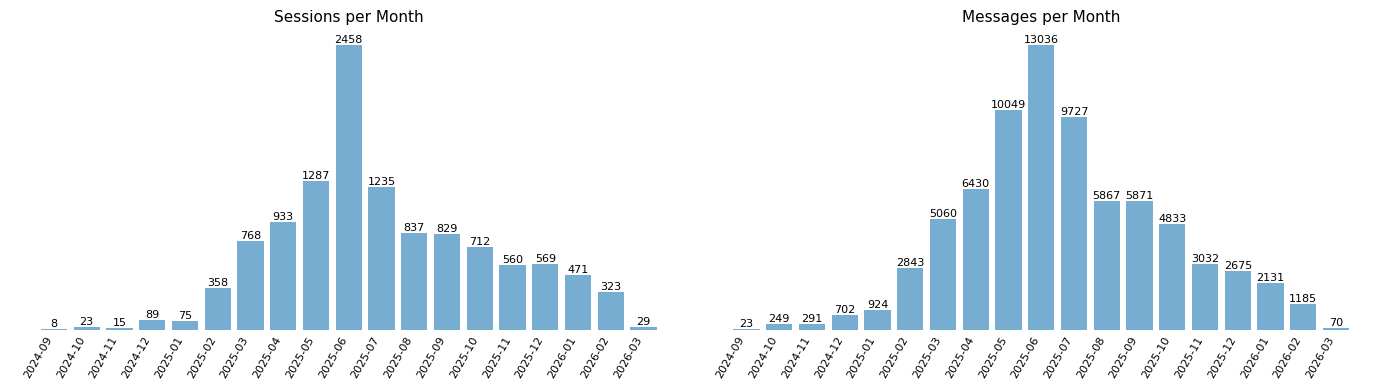


Month | Sessions | Messages | Msg/Session
---------------------------------------------
2024-09           8         23        2.88
2024-10          23        249       10.83
2024-11          15        291       19.40
2024-12          89        702        7.89
2025-01          75        924       12.32
2025-02         358       2843        7.94
2025-03         768       5060        6.59
2025-04         933       6430        6.89
2025-05        1287      10049        7.81
2025-06        2458      13036        5.30
2025-07        1235       9727        7.88
2025-08         837       5867        7.01
2025-09         829       5871        7.08
2025-10         712       4833        6.79
2025-11         560       3032        5.41
2025-12         569       2675        4.70
2026-01         471       2131        4.52
2026-02         323       1185        3.67
2026-03          29         70        2.41


In [8]:
import matplotlib.pyplot as plt

# Session-level: deduplicate to one row per session
sessions = df_classifications.drop_duplicates(subset=["sha"]).copy()
sessions["month"] = pd.to_datetime(sessions["timestamp"]).dt.to_period("M")

# Message-level: deduplicate to one row per (sha, index_in_chat)
messages = df_classifications.drop_duplicates(subset=["sha", "index_in_chat"]).copy()
messages["month"] = pd.to_datetime(messages["timestamp"]).dt.to_period("M")

monthly_sessions = sessions.groupby("month").size()
monthly_messages = messages.groupby("month").size()

# Align index
all_months = monthly_sessions.index.union(monthly_messages.index)
monthly_sessions = monthly_sessions.reindex(all_months, fill_value=0)
monthly_messages = monthly_messages.reindex(all_months, fill_value=0)
month_labels = all_months.astype(str)


def _bar_chart(ax, values, title):
    bars = ax.bar(month_labels, values, alpha=0.6)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_yticks([])
    ax.tick_params(axis="x", length=0)
    ax.set_title(title, fontsize=11)
    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h,
            f"{int(h)}",
            ha="center",
            va="bottom",
            fontsize=8,
        )
    plt.setp(ax.get_xticklabels(), rotation=60, ha="right", fontsize=8)


fig, axes = plt.subplots(1, 2, figsize=(14, 4))
_bar_chart(axes[0], monthly_sessions.values, "Sessions per Month")
_bar_chart(axes[1], monthly_messages.values, "Messages per Month")

plt.tight_layout()
plt.show()

print("\nMonth | Sessions | Messages | Msg/Session")
print("-" * 45)
for m in all_months:
    s = monthly_sessions[m]
    msg = monthly_messages[m]
    ratio = msg / s if s > 0 else 0
    print(f"{str(m):<10} {s:>8}  {msg:>9}  {ratio:>10.2f}")

Monthly subcategory proportion trend (2025-02 to 2026-02)
Sub-category                                  slope(pp/mo)     R²          p   mean%   sig
------------------------------------------------------------------------------------------
1.3 Alignment Correction                      ↓     0.217  0.782     0.0001   3.97%   ***
3.1 Planning & Decision Consultation          ↑     0.195  0.578     0.0026   6.50%    **
6.2 Toolchain Operation                       ↑     0.327  0.461     0.0107   8.01%     *
2.3 Error Persistence                         ↓     0.077  0.342     0.0358   2.54%     *
7.5 Sentiment Expression                      ↓     0.062  0.328     0.0407   1.16%     *
4.2 Behavior Specification                    ↑     0.109  0.326     0.0417   3.74%     *
5.1 Code Review                               ↓     0.046  0.215     0.1106   1.95%      
2.1 Log Paste                                 ↓     0.211  0.203     0.1223   7.00%      
6.1 Documentation                       

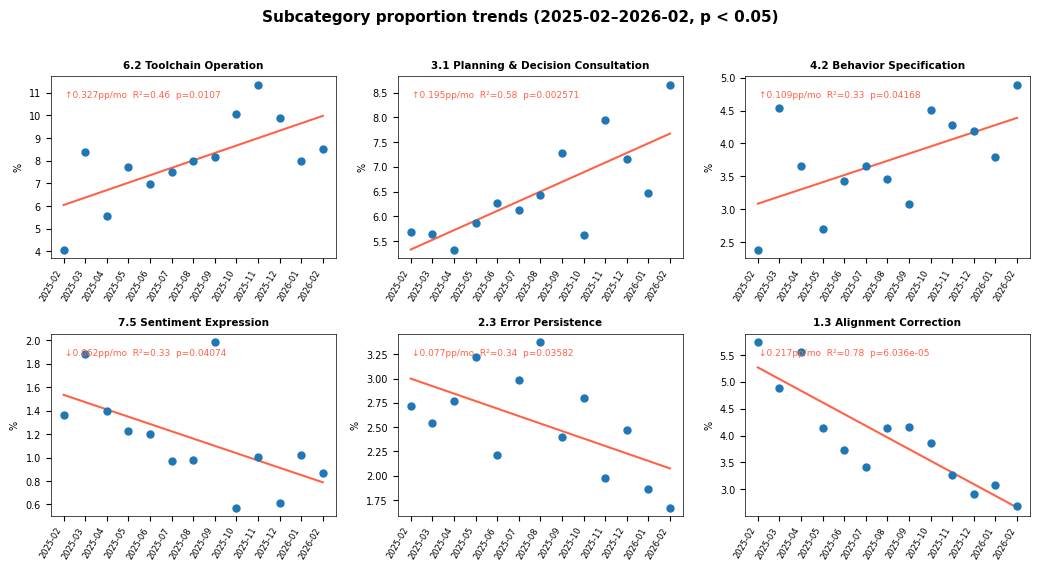

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# ── 1. Message-level deduplication with fractional label weight ───────────────
# Each (sha, index_in_chat) contributes weight 1/n_labels to each of its labels
df = df_classifications.copy()
df["month"] = pd.to_datetime(df["timestamp"]).dt.to_period("M")

# Count labels per message
label_counts = df.groupby(["sha", "index_in_chat"])["sub_category"].transform("count")
df["label_weight"] = 1.0 / label_counts

# ── 2. Monthly weighted count per subcategory ─────────────────────────────────
monthly_sub = (
    df.groupby(["month", "sub_category"])["label_weight"]
    .sum()
    .reset_index()
    .rename(columns={"label_weight": "weighted_count"})
)

# Monthly total message count (sum of weights = number of unique messages)
monthly_total = (
    df.groupby(["month", "sha", "index_in_chat"])["label_weight"]
    .first()  # one row per message per month
    .reset_index()
    .groupby("month")["label_weight"]
    .count()  # just count messages
    .reset_index()
    .rename(columns={"label_weight": "total_messages"})
)

monthly_sub = monthly_sub.merge(monthly_total, on="month")
monthly_sub["proportion"] = (
    monthly_sub["weighted_count"] / monthly_sub["total_messages"]
)

# ── 3. Filter to months with sufficient volume ────────────────────────────────
MONTH_MIN = "2025-02"
MONTH_MAX = "2026-02"
mask = (monthly_sub["month"].astype(str) >= MONTH_MIN) & (
    monthly_sub["month"].astype(str) <= MONTH_MAX
)
monthly_filtered = monthly_sub[mask].copy()

months_ordered = sorted(monthly_filtered["month"].unique())
month_index = {m: i for i, m in enumerate(months_ordered)}
monthly_filtered["month_idx"] = monthly_filtered["month"].map(month_index)

# ── 4. Regression per subcategory ─────────────────────────────────────────────
sub_categories = sorted(df["sub_category"].dropna().unique())

results = []
for cat in sub_categories:
    cat_data = monthly_filtered[monthly_filtered["sub_category"] == cat].sort_values(
        "month_idx"
    )
    if len(cat_data) < 6:
        continue
    x = cat_data["month_idx"].values
    y = cat_data["proportion"].values
    slope, intercept, r, p, se = stats.linregress(x, y)
    results.append(
        {
            "sub_category": cat,
            "slope": slope,
            "slope_pct_pt": slope * 100,  # percentage point change per month
            "r2": r**2,
            "p": p,
            "mean_proportion": y.mean(),
        }
    )

results_df = pd.DataFrame(results).sort_values("r2", ascending=False)

# ── 5. Print regression table ─────────────────────────────────────────────────
print(f"Monthly subcategory proportion trend ({MONTH_MIN} to {MONTH_MAX})")
print(
    f"{'Sub-category':<45} {'slope(pp/mo)':>12} {'R²':>6} {'p':>10} {'mean%':>7} {'sig':>5}"
)
print("-" * 90)
for _, row in results_df.iterrows():
    sig = (
        "***"
        if row["p"] < 0.001
        else "**" if row["p"] < 0.01 else "*" if row["p"] < 0.05 else ""
    )
    direction = "↑" if row["slope"] > 0 else "↓"
    print(
        f"{row['sub_category']:<45} "
        f"{direction}{abs(row['slope_pct_pt']):>10.3f} "
        f"{row['r2']:>6.3f} "
        f"{row['p']:>10.4f} "
        f"{row['mean_proportion']*100:>6.2f}% "
        f"{sig:>5}"
    )

# ── 6. Plot: only subcategories with p < 0.05 ────────────────────────────────
significant = results_df[results_df["p"] < 0.05].sort_values("slope", ascending=False)

if len(significant) == 0:
    print("\nNo subcategory with p < 0.05")
else:
    n_cats = len(significant)
    ncols = 3
    nrows = int(np.ceil(n_cats / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 2.8))
    axes = axes.flatten() if n_cats > 1 else [axes]

    x_labels = [str(m) for m in months_ordered]

    for i, (_, row) in enumerate(significant.iterrows()):
        ax = axes[i]
        cat = row["sub_category"]
        cat_data = monthly_filtered[
            monthly_filtered["sub_category"] == cat
        ].sort_values("month_idx")
        x = cat_data["month_idx"].values
        y = cat_data["proportion"].values * 100  # as percentage

        ax.scatter(x, y, s=25, zorder=3)
        # Regression line
        x_fit = np.linspace(x.min(), x.max(), 100)
        y_fit = (row["slope"] * x_fit + (y / 100 - row["slope"] * x).mean()) * 100
        ax.plot(x_fit, y_fit, color="tomato", linewidth=1.5)

        ax.set_title(cat, fontsize=7.5, fontweight="bold")
        ax.set_xticks(range(len(months_ordered)))
        ax.set_xticklabels(x_labels, rotation=60, ha="right", fontsize=6)
        ax.tick_params(axis="y", labelsize=7)
        ax.set_ylabel("%", fontsize=7)

        direction = "↑" if row["slope"] > 0 else "↓"
        ax.text(
            0.05,
            0.92,
            f"{direction}{abs(row['slope_pct_pt']):.3f}pp/mo  R²={row['r2']:.2f}  p={row['p']:.4g}",
            transform=ax.transAxes,
            fontsize=6.5,
            color="tomato",
            verticalalignment="top",
        )

        for spine in ax.spines.values():
            spine.set_linewidth(0.5)

    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(
        f"Subcategory proportion trends ({MONTH_MIN}–{MONTH_MAX}, p < 0.05)",
        fontsize=11,
        fontweight="bold",
        y=1.01,
    )
    plt.tight_layout()
    plt.show()